# Denoising Convolutional Autoencoder
## Part 1 — MNIST Baseline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

### 1. Load & Pre-process MNIST

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize to [0, 1] and add channel dimension
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print(f"Train: {x_train.shape}  |  Test: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1)  |  Test: (10000, 28, 28, 1)


### 2. Add Gaussian Noise

In [3]:
def add_noise(images: np.ndarray, factor: float) -> np.ndarray:
    """Add Gaussian noise and clip values to [0, 1]."""
    noisy = images + factor * np.random.normal(size=images.shape)
    return np.clip(noisy, 0.0, 1.0)

NOISE_LOW  = 0.1
NOISE_HIGH = 0.5

x_train_noisy_low  = add_noise(x_train, NOISE_LOW)
x_train_noisy_high = add_noise(x_train, NOISE_HIGH)
x_test_noisy_low   = add_noise(x_test,  NOISE_LOW)
x_test_noisy_high  = add_noise(x_test,  NOISE_HIGH)

### 3. Visualise Original vs Noisy Samples

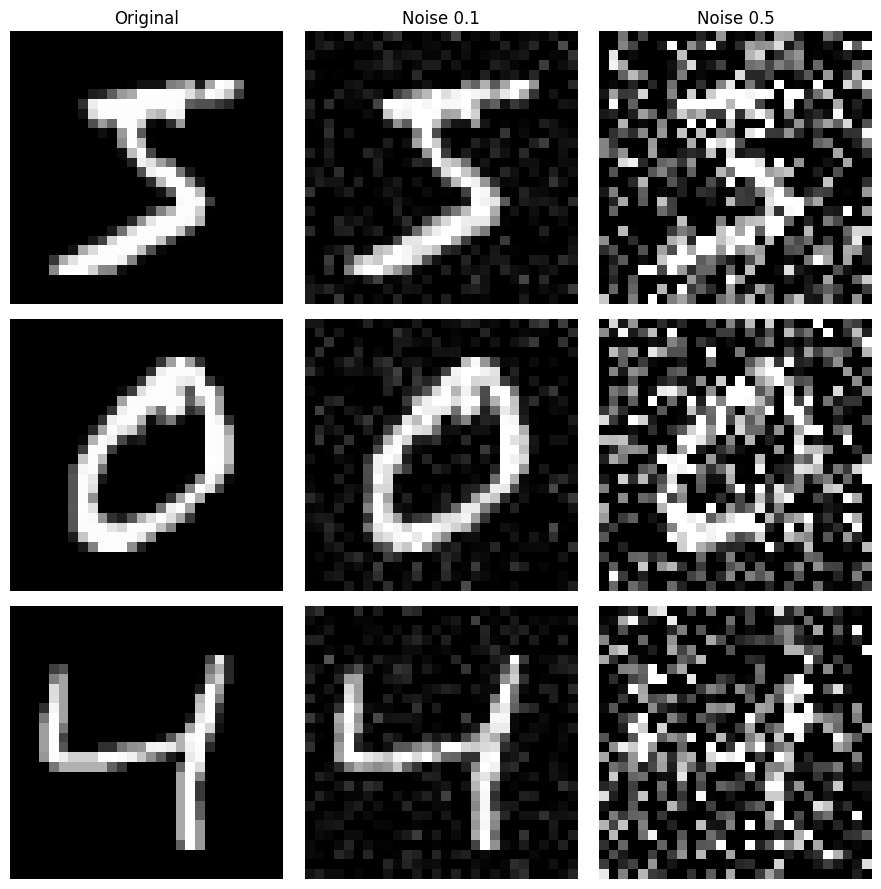

In [4]:
def show_noise_comparison(clean, noisy_low, noisy_high, n: int = 3) -> None:
    """Display n samples across three noise levels in a grid."""
    _, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    col_titles = ["Original", f"Noise {NOISE_LOW}", f"Noise {NOISE_HIGH}"]

    for col, (title, data) in enumerate(zip(col_titles, [clean, noisy_low, noisy_high])):
        for row in range(n):
            axes[row, col].imshow(data[row].reshape(28, 28), cmap='gray')
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(title, fontsize=12)

    plt.tight_layout()
    plt.show()

show_noise_comparison(x_train, x_train_noisy_low, x_train_noisy_high)

### 4. Build the Convolutional Autoencoder

In [5]:
def build_encoder(input_shape: tuple = (28, 28, 1)):
    """Encoder: two Conv+MaxPool blocks producing a compressed latent map."""
    inp = Input(shape=input_shape, name="encoder_input")
    x   = Conv2D(32, (3, 3), activation='relu', padding='same')(inp)
    x   = MaxPooling2D((2, 2), padding='same')(x)
    x   = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    enc = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return inp, enc


def build_decoder(encoded):
    """Decoder: mirrors the encoder with UpSampling to reconstruct the image."""
    x   = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x   = UpSampling2D((2, 2))(x)
    x   = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x   = UpSampling2D((2, 2))(x)
    dec = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return dec


def build_autoencoder(input_shape: tuple = (28, 28, 1), lr: float = 1e-3) -> Model:
    """Assemble and compile the full autoencoder."""
    inp, enc = build_encoder(input_shape)
    dec      = build_decoder(enc)
    model    = Model(inputs=inp, outputs=dec, name="denoising_autoencoder")
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy')
    return model

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Train

In [6]:
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test),
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 183s 387ms/step - loss: 0.1586 - val_loss: 0.1160
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 377ms/step - loss: 0.1113 - val_loss: 0.1064
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 381ms/step - loss: 0.1057 - val_loss: 0.1028
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 374ms/step - loss: 0.1028 - val_loss: 0.1010
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 373ms/step - loss: 0.1011 - val_loss: 0.0993
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 379ms/step - loss: 0.0998 - val_loss: 0.0987
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 373ms/step - loss: 0.0989 - val_loss: 0.0977
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 178s 381ms/step - loss: 0.0981 - val_loss: 0.0970
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 372ms/step - loss: 0.0973 - val_loss: 0.0970
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 174s 372ms/step - loss: 0.0968 - val_loss: 0.0962


### 6. Evaluate — Denoised Reconstructions

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


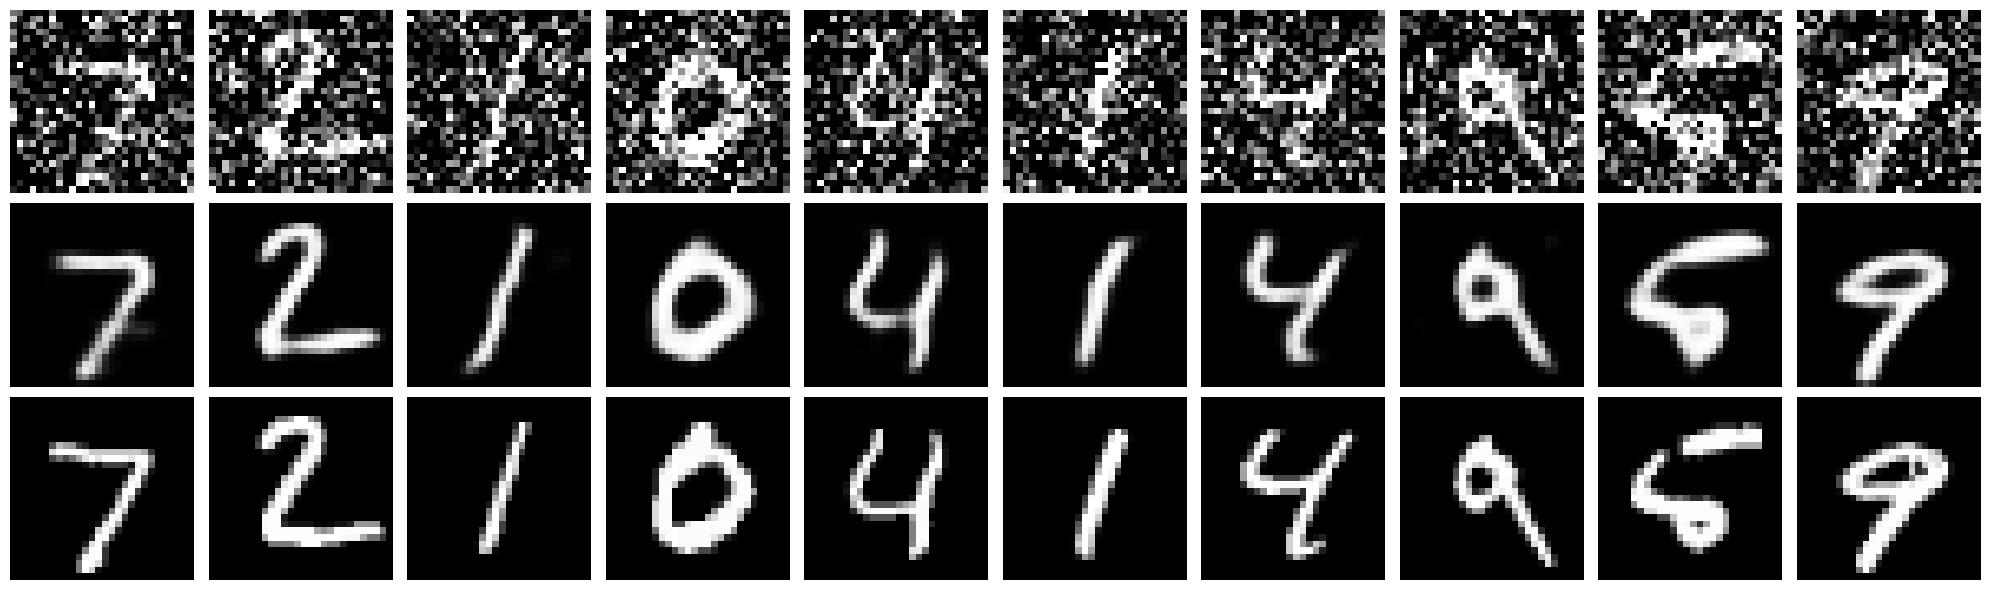

In [7]:
denoised = autoencoder.predict(x_test_noisy_high)

def plot_reconstruction(noisy, denoised, clean, n: int = 10) -> None:
    """Show noisy / denoised / clean triplets side by side."""
    _, axes = plt.subplots(3, n, figsize=(2 * n, 6))
    row_labels = ["Noisy", "Denoised", "Clean"]

    for col in range(n):
        for row, img_set in enumerate([noisy, denoised, clean]):
            axes[row, col].imshow(img_set[col].reshape(28, 28), cmap='gray')
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(row_labels[row], fontsize=11)

    plt.tight_layout()
    plt.show()

plot_reconstruction(x_test_noisy_high, denoised, x_test)

---
## Part 2 — Exercise: Devanagari Handwritten Digit Dataset

In [10]:
import os
from PIL import Image

### 1. Load Devanagari Dataset

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# Update DATA_PATH to wherever DevanagariHandwrittenDigitDataset lives
DATA_PATH  = '/content/drive/MyDrive/AI/DevanagariHandwrittenDigitDataset'
TRAIN_PATH = os.path.join(DATA_PATH, 'Train')
TEST_PATH  = os.path.join(DATA_PATH, 'Test')

IMG_SIZE = (28, 28)

def load_images(folder: str, img_size: tuple = IMG_SIZE) -> np.ndarray:
    """Recursively load grayscale images from class sub-folders."""
    images = []
    for cls in sorted(os.listdir(folder)):
        cls_dir = os.path.join(folder, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            try:
                img = Image.open(fpath).convert('L').resize(img_size)
                images.append(np.array(img))
            except Exception:
                pass  # skip corrupt files silently
    return np.array(images)

x_train = load_images(TRAIN_PATH)
x_test  = load_images(TEST_PATH)
print(f"Train: {x_train.shape}  |  Test: {x_test.shape}")

Train: (17000, 28, 28)  |  Test: (3000, 28, 28)


### 2. Normalise & Add Noise

In [13]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

x_train_noisy_low  = add_noise(x_train, NOISE_LOW)
x_train_noisy_high = add_noise(x_train, NOISE_HIGH)
x_test_noisy_low   = add_noise(x_test,  NOISE_LOW)
x_test_noisy_high  = add_noise(x_test,  NOISE_HIGH)

### 3. Visualise One Sample per Digit Class

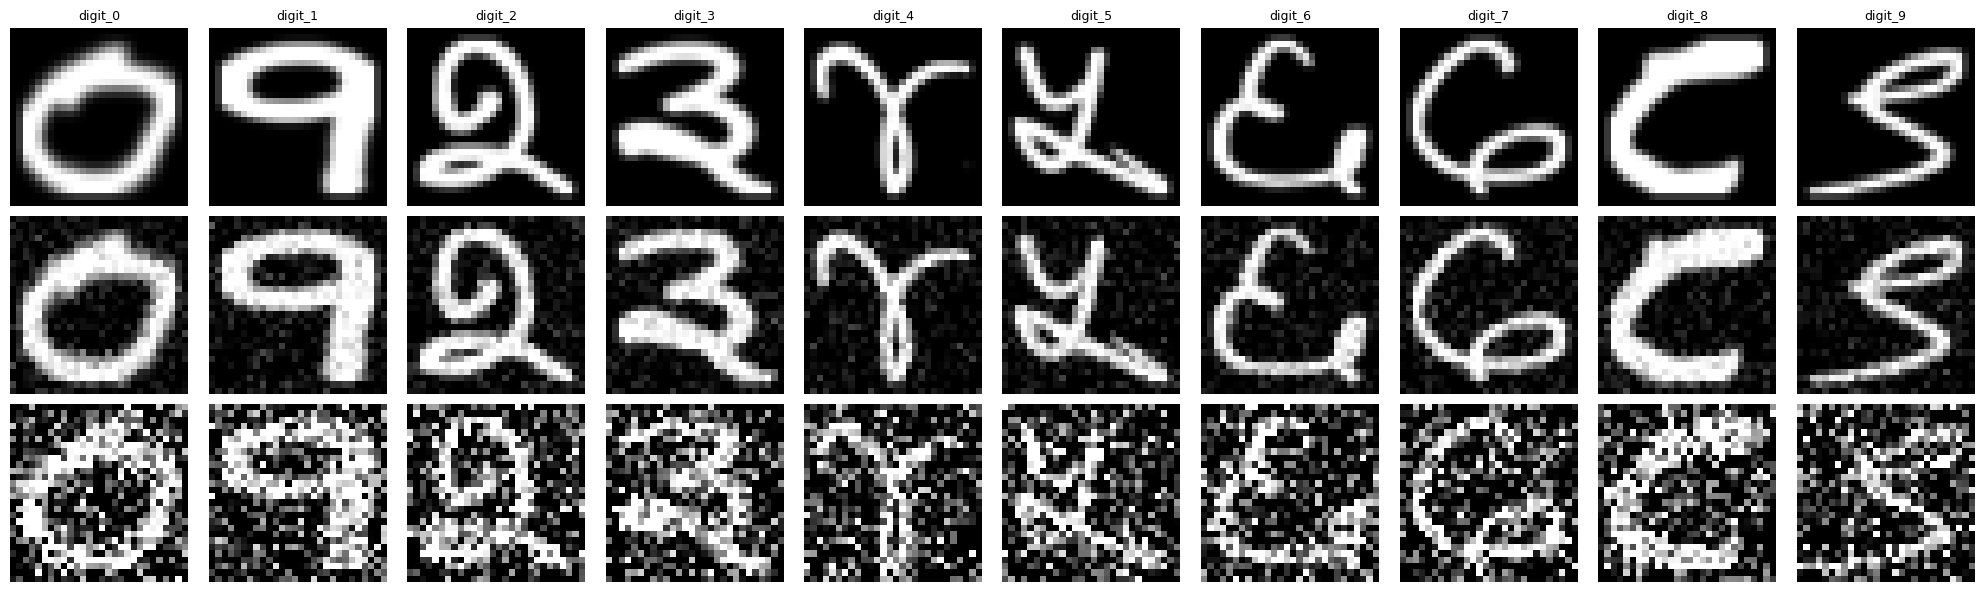

In [14]:
def get_class_representatives(folder: str, images: np.ndarray):
    """Return (label, index) for the first image of each class."""
    classes = sorted(
        c for c in os.listdir(folder) if os.path.isdir(os.path.join(folder, c))
    )
    counts, reps, cumsum = {}, [], 0
    for cls in classes:
        n = len(os.listdir(os.path.join(folder, cls)))
        reps.append((cls, cumsum))
        cumsum += n
    return reps

class_reps = get_class_representatives(TRAIN_PATH, x_train)
n_cls      = len(class_reps)

fig, axes = plt.subplots(3, n_cls, figsize=(2 * n_cls, 6))
row_labels = ["Original", f"Noise {NOISE_LOW}", f"Noise {NOISE_HIGH}"]

for col, (label, idx) in enumerate(class_reps):
    for row, src in enumerate([x_train, x_train_noisy_low, x_train_noisy_high]):
        axes[row, col].imshow(src[idx].reshape(28, 28), cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(label, fontsize=9)

for row, lbl in enumerate(row_labels):
    axes[row, 0].set_ylabel(lbl, fontsize=10)

plt.tight_layout()
plt.show()

### 4. Build & Train Autoencoder on Devanagari

In [15]:
autoencoder = build_autoencoder()  # same architecture as Part 1
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test),
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 456ms/step - loss: 0.3119 - val_loss: 0.2146
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 55s 412ms/step - loss: 0.2076 - val_loss: 0.2005
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 53s 401ms/step - loss: 0.1981 - val_loss: 0.1962
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 83s 411ms/step - loss: 0.1935 - val_loss: 0.1916
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 52s 394ms/step - loss: 0.1905 - val_loss: 0.1897
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 83s 401ms/step - loss: 0.1882 - val_loss: 0.1874
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 52s 393ms/step - loss: 0.1868 - val_loss: 0.1866
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 83s 400ms/step - loss: 0.1859 - val_loss: 0.1851
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 84s 415ms/step - loss: 0.1850 - val_loss: 0.1855
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 53s 398ms/step - loss: 0.1842 - val_loss: 0.1842


### 5. Evaluate — Reconstructions

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


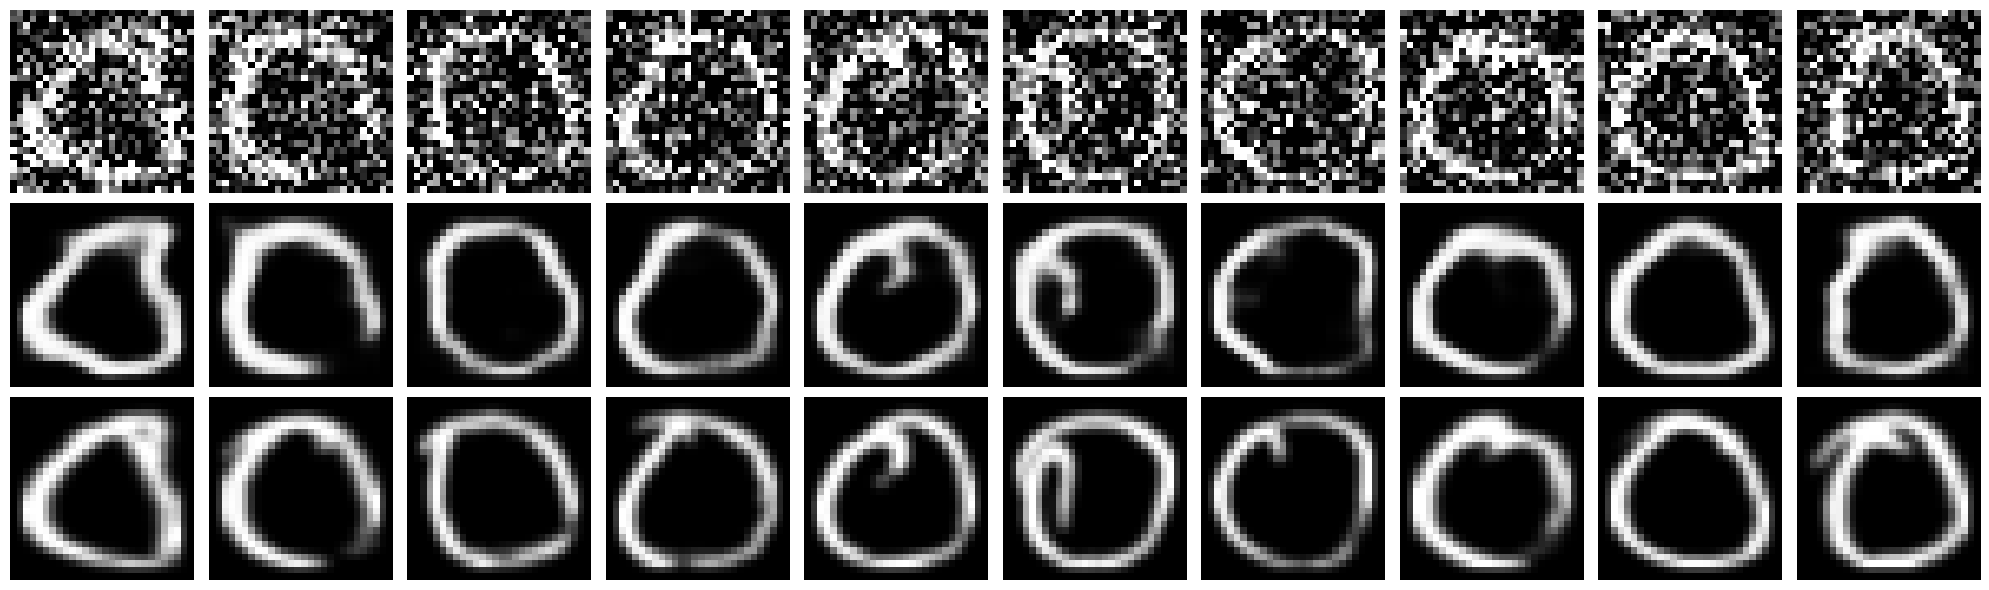

In [17]:
denoised = autoencoder.predict(x_test_noisy_high)
plot_reconstruction(x_test_noisy_high, denoised, x_test)

### 6. Training Curve

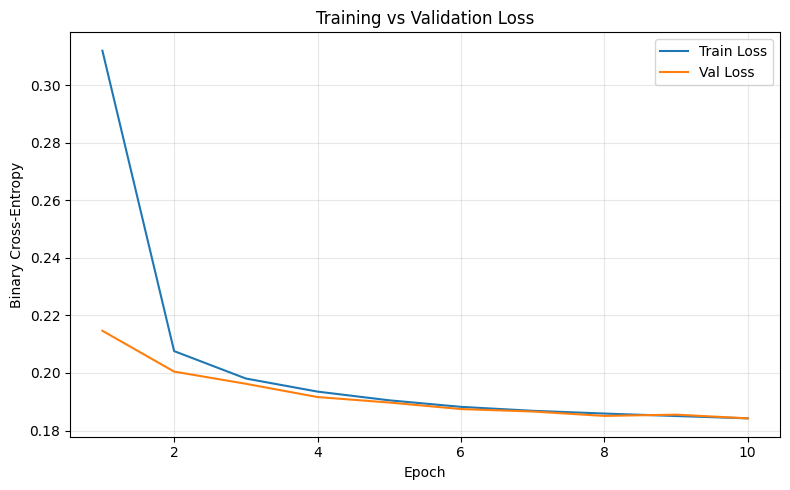

In [18]:
def plot_loss(history) -> None:
    """Plot training vs validation loss over epochs."""
    epochs = range(1, len(history.history['loss']) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history.history['loss'],     label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], label='Val Loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Cross-Entropy')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_loss(history)